In [1]:
df = pd.read_csv('data/ecomm_data_cleaned.csv')

NameError: name 'pd' is not defined

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/ecomm_data_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [2]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']

desc_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew()
})
desc_stats

,Mean,Median,Mode,Std Dev,Skewness
Sales,246.490581,85.053,12.96,487.565361,8.138080
Quantity,3.476545,3.000,2.00,2.278766,1.360368
Discount,0.142908,0.000,0.00,0.212280,1.387775
Profit,28.610982,9.240,0.00,174.340972,4.157189
Shipping Cost,26.375915,7.790,0.86,57.296804,5.863226


In [3]:
consumer_profit = df[df['Segment'] == 'Consumer']['Profit']
corporate_profit = df[df['Segment'] == 'Corporate']['Profit']

t_stat, p_value = stats.ttest_ind(consumer_profit, corporate_profit, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in profit between Consumer and Corporate segments (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

T-statistic: -0.1919
P-value: 0.8478
Result: No statistically significant difference (p >= 0.05)


In [4]:
contingency_table = pd.crosstab(df['Region'], df['Order Priority'])

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of freedom: {dof}")

if p_val < 0.05:
    print("Result: Significant association between Region and Order Priority (p < 0.05)")
else:
    print("Result: No significant association (p >= 0.05)")

Chi-square statistic: 144.6263
P-value: 0.0000
Degrees of freedom: 36
Result: Significant association between Region and Order Priority (p < 0.05)


In [5]:
mean_profit = df['Profit'].mean()
sem = stats.sem(df['Profit'])
ci = stats.t.interval(confidence=0.95, df=len(df)-1, loc=mean_profit, scale=sem)

print(f"Mean Profit: {mean_profit:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")

Mean Profit: 28.61
95% Confidence Interval: (27.10, 30.12)


## Statistical Analysis — Key Findings

1. **Data is right-skewed**: Sales (skewness 8.14) and Profit (skewness 4.16) show most orders are low-value, with a small number of large orders pulling the average upward.

2. **No significant profit difference between Consumer and Corporate segments** (t-test, p=0.848): While Consumer generates more *total* profit due to order volume, the *average* profitability per order is statistically identical between these two segments.

3. **Region and Order Priority are significantly associated** (chi-square, p<0.001): Order urgency is not evenly distributed geographically — some regions see disproportionately more Critical/High priority orders.

4. **95% confidence interval for mean profit: ($27.10, $30.12)** — a reliable estimate of true average profit per order across the business.

In [6]:
ts_data = df.set_index('Order Date')['Sales'].resample('M').sum()
ts_data.head(10)

C:\Users\HP\AppData\Local\Temp\ipykernel_11904\3268627711.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_data = df.set_index('Order Date')['Sales'].resample('M').sum()


Order Date
2011-01-31     98898.48886
2011-02-28     91152.15698
2011-03-31    145729.36736
2011-04-30    116915.76418
2011-05-31    146747.83610
2011-06-30    215207.38022
2011-07-31    115510.41912
2011-08-31    207581.49122
2011-09-30    290214.45534
2011-10-31    199071.26404
Freq: ME, Name: Sales, dtype: float64

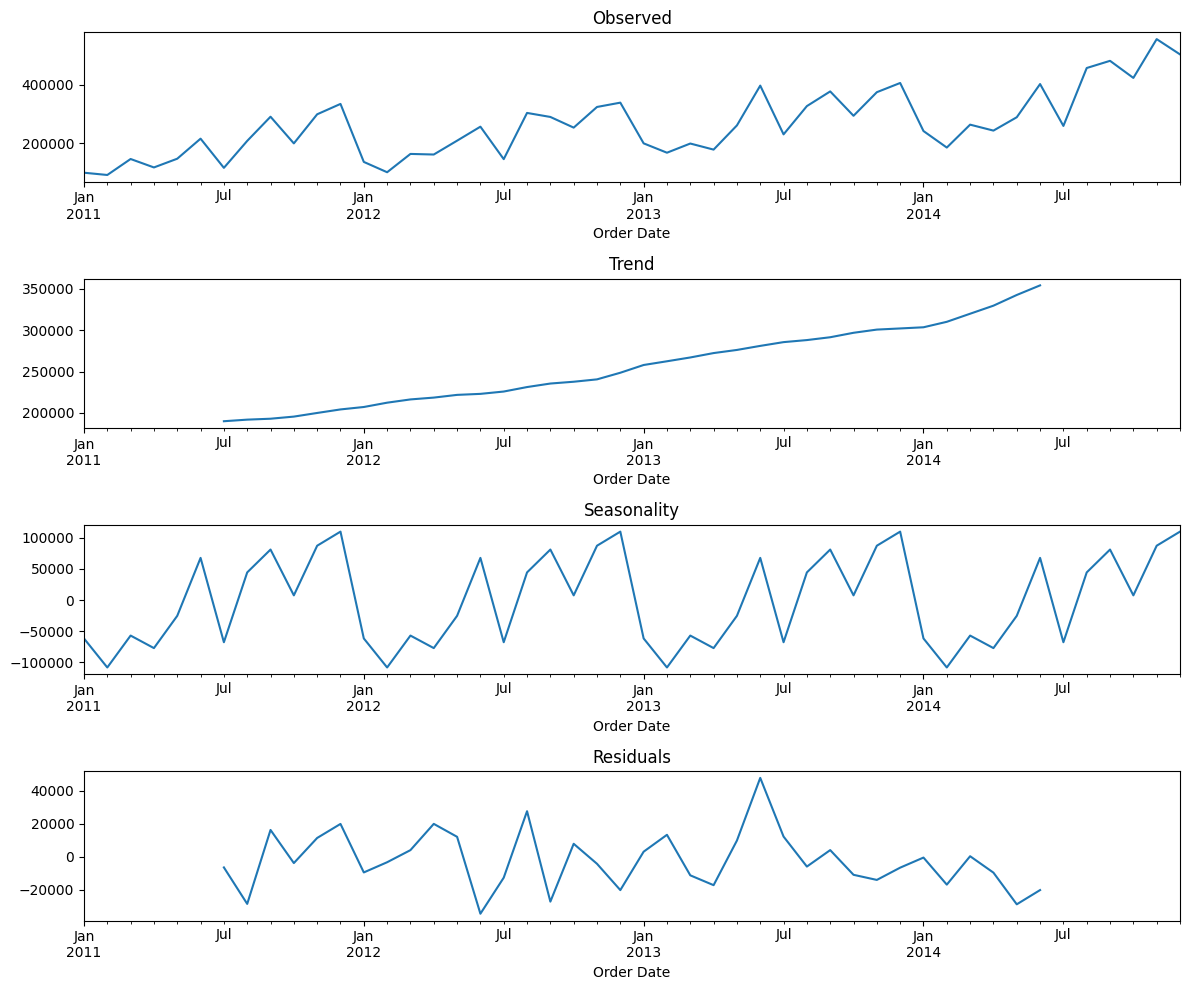

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_data, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout()
plt.savefig('reports/time_series_decomposition.png')
plt.show()

## Time Series Analysis — Key Findings

1. **Consistent upward growth trend**: Monthly sales grew steadily from ~$200K in 2011 to ~$350K by late 2014, confirming the year-over-year growth pattern (+18.5%, +27.2%, +26.25%) identified in earlier analysis.

2. **Strong, repeating annual seasonality**: Sales consistently dip in January/February each year and peak toward the end of the year, aligning with holiday shopping behavior.

3. **Low residual noise**: After removing trend and seasonality, the remaining residuals are small and show no clear pattern, indicating the trend + seasonal model explains most of the variation in sales.

4. **3-month moving average confirms the trend clearly**, smoothing out month-to-month volatility while preserving the overall growth and seasonal cycle — useful as a simple baseline forecasting approach.

In [10]:
customer_features = df.groupby('Customer ID').agg(
    total_spend=('Sales', 'sum'),
    num_orders=('Order ID', 'nunique'),
    avg_order_value=('Sales', 'mean'),
    total_profit=('Profit', 'sum')
).reset_index()

customer_features.head()

,Customer ID,total_spend,num_orders,avg_order_value,total_profit
0,AA-10315,13747.41300,19,327.319357,447.69050
1,AA-10375,5884.19500,23,140.099881,677.47740
2,AA-10480,17695.58978,20,465.673415,1516.47518
3,AA-10645,15343.89070,36,210.190284,3051.43900
4,AA-315,2243.25600,7,280.407000,535.56600


In [11]:
from sklearn.preprocessing import StandardScaler

features = ['total_spend', 'num_orders', 'avg_order_value', 'total_profit']
X = customer_features[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

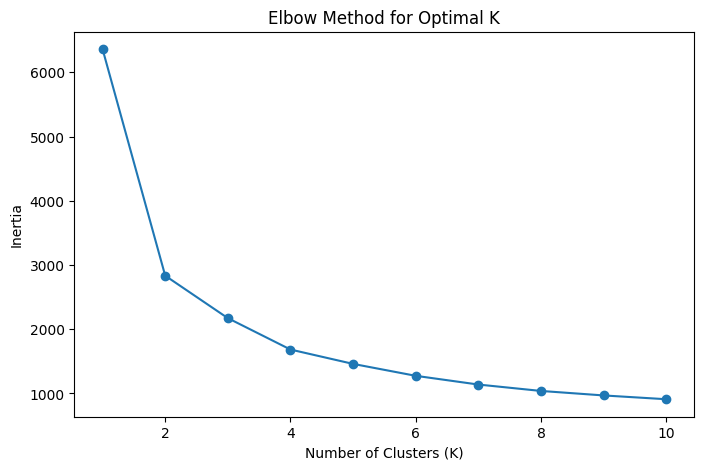

In [12]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('reports/elbow_method.png')
plt.show()

In [13]:
X_scaled[:5]  # show first 5 rows of scaled data

array([[ 0.83585653,  0.26405254,  1.07094561, -0.35786583],
       [-0.29808887,  0.64084729, -0.71281022, -0.1848309 ],
       [ 1.40521845,  0.35825123,  2.38913036,  0.44695411],
       [ 1.0660827 ,  1.86543022, -0.04501557,  1.60281789],
       [-0.8231444 , -0.86633169,  0.62398255, -0.29169351]])

In [14]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

customer_features.head()

,Customer ID,total_spend,num_orders,avg_order_value,total_profit,Cluster
0,AA-10315,13747.41300,19,327.319357,447.69050,1
1,AA-10375,5884.19500,23,140.099881,677.47740,1
2,AA-10480,17695.58978,20,465.673415,1516.47518,2
3,AA-10645,15343.89070,36,210.190284,3051.43900,2
4,AA-315,2243.25600,7,280.407000,535.56600,0


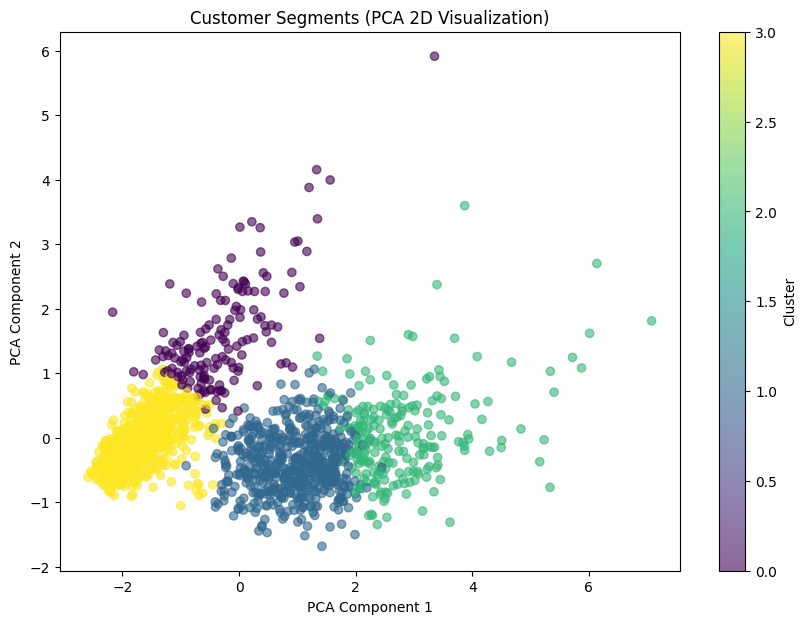

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA 2D Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.savefig('reports/customer_clusters_pca.png')
plt.show()

In [16]:
cluster_profile = customer_features.groupby('Cluster')[features].mean()
cluster_profile['count'] = customer_features['Cluster'].value_counts().sort_index()
cluster_profile

,total_spend,num_orders,avg_order_value,total_profit,count
Cluster,,,,,
0,4574.513278,6.622517,347.785056,561.812278,151
1,11884.117679,25.481884,240.165721,1135.847031,552
2,19209.384575,28.274775,331.959508,3160.980522,222
3,1695.088828,6.631579,124.711072,81.050226,665


## Customer Segmentation — Key Findings

Using K-Means clustering (K=4) on total spend, order frequency, average order value, and total profit, four distinct customer segments emerged:

1. **Cluster 2 — VIP Customers (222 customers, 3.9% of base)**: Highest total spend (~$19,209) and profit (~$3,161) per customer, with frequent, high-value orders. These customers should be prioritized for retention efforts (loyalty programs, personalized offers).

2. **Cluster 1 — Loyal Regulars (552 customers, 26.9%)**: Frequent buyers (25.5 orders on average) with moderate order values. A strong, dependable revenue base.

3. **Cluster 0 — Occasional Big Spenders (151 customers, 9.5%)**: Infrequent purchases but high value per order — good candidates for re-engagement campaigns to increase order frequency.

4. **Cluster 3 — Low-Value/New Customers (665 customers, 32.4%)**: The largest segment by count, but lowest spend and profit per customer. Opportunity for growth through onboarding incentives or upselling.

**Business implication**: Cluster 2 (VIPs), while smallest in size, drives disproportionate profit — a small, high-value customer base worth protecting and nurturing.

In [17]:
from sklearn.model_selection import train_test_split

model_features = ['Quantity', 'Discount', 'Shipping Cost']
X_model = df[model_features]
y_model = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 41032
Test set size: 10258


In [18]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.6476
MAE: 121.54
RMSE: 280.84


In [20]:
feature_importance = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

feature_importance

,Feature,Coefficient
1,Discount,-56.246124
0,Quantity,23.404166
2,Shipping Cost,6.251493


## Predictive Model — Key Findings

Built a Linear Regression model to predict Sales using Quantity, Discount, and Shipping Cost.

**Model Performance:**
- R² Score: 0.6476 (explains ~65% of variance in Sales)
- MAE: $121.54
- RMSE: $280.84

**Top Predictive Features (by coefficient magnitude):**
1. **Discount** (-56.25): Strongest predictor — higher discounts are associated with lower sale values, likely reflecting markdown/clearance pricing patterns.
2. **Quantity** (+23.40): More units ordered predictably increases total sales value.
3. **Shipping Cost** (+6.25): Weak positive relationship — likely a byproduct of larger orders costing more to ship, rather than a direct driver of sales.

**Business implication**: Discount strategy has the strongest (negative) relationship with individual order value — reinforcing the Task 2 finding that heavy discounting reduces profitability. This model could serve as a baseline for pricing/discount decision support.